# FinTrust Digital Bank — Week 1: Data Profiling & Problem Definition

**AnalystLab Africa Experience Lab Internship — Data Science Track**
**Intern:** Takudzwa Jeffrey Gumbo (TJ) | **Week 1 — Understand & Plan**

---

### Purpose of this notebook

Week 1 is a planning week. This notebook does **not** train a model. It profiles the two supplied
datasets so that every figure quoted in the Week 1 report is reproducible and traceable to code.

Specifically it:

1. Loads the customer and transaction datasets with explicit types.
2. Profiles structure, data types, missingness and duplicates.
3. Verifies the join relationship between the two datasets.
4. Assesses the modelling target, `Risk_Review_Flag`.
5. Records data-quality observations for treatment in Week 2.
6. Produces descriptive profiling of the target against candidate features.
7. Saves all figures to `reports/figures/`.

### Responsible-use statement

> All FinTrust customers, transactions and labels are **synthetic** and created for educational
> purposes. `Risk_Review_Flag` is a synthetic educational label, **not** a real fraud determination.
> Nothing in this notebook may be presented as a finding about real customers or real financial crime.

### What is deliberately NOT done here

No cleaning, no imputation, no feature engineering and no modelling. Those begin in Week 2, after the
train/validation/test split, so that exploratory analysis cannot leak into feature decisions.

## 1. Setup

In [24]:
"""Imports, display options and reproducibility settings."""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display options
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Project colours, used consistently across every figure
NAVY, GOLD, GREY = "#1F3B63", "#D4A017", "#8C93A0"


BASE_DIR = Path("/content/drive/MyDrive/Analyst Lab Africa")

FIG_DIR = BASE_DIR / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


CUSTOMER_FILE = BASE_DIR / "FinTrust_Customer_Data - FinTrust_Customer_Data.csv"

TRANSACTION_FILE = BASE_DIR / "FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv"


print("Customer file exists:", CUSTOMER_FILE.exists())
print("Transaction file exists:", TRANSACTION_FILE.exists())

print("\nCustomer file:")
print(CUSTOMER_FILE)

print("\nTransaction file:")
print(TRANSACTION_FILE)

print(f"\npandas {pd.__version__} | numpy {np.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Customer file exists: True
Transaction file exists: True

Customer file:
/content/drive/MyDrive/Analyst Lab Africa/FinTrust_Customer_Data - FinTrust_Customer_Data.csv

Transaction file:
/content/drive/MyDrive/Analyst Lab Africa/FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv

pandas 2.2.3 | numpy 2.1.3


## 2. Load the data

Timestamps are parsed with an explicit format string rather than relying on inference, so that a change in the source file fails loudly instead of silently producing wrong dates.

In [25]:
def load_customers(path: Path) -> pd.DataFrame:
    """Load the FinTrust customer dataset.

    Args:
        path: Path to FinTrust_Customer_Data.csv.

    Returns:
        DataFrame of customer records, one row per customer.
    """
    return pd.read_csv(path)


def load_transactions(path: Path, datetime_format: str = "%m/%d/%Y %H:%M") -> pd.DataFrame:
    """Load the FinTrust transaction dataset and parse the timestamp column.

    Args:
        path: Path to FinTrust_Transaction_Data.csv.
        datetime_format: Explicit strptime format for Transaction_DateTime.

    Returns:
        DataFrame of transaction records with a parsed Transaction_DateTime column.

    Raises:
        ValueError: If any timestamp fails to parse, which would silently corrupt
            every time-derived feature downstream.
    """
    df = pd.read_csv(path)
    parsed = pd.to_datetime(df["Transaction_DateTime"], format=datetime_format, errors="coerce")
    if parsed.isna().any():
        raise ValueError(f"{parsed.isna().sum()} timestamps failed to parse with {datetime_format!r}")
    df["Transaction_DateTime"] = parsed
    return df


customers = load_customers(CUSTOMER_FILE)
transactions = load_transactions(TRANSACTION_FILE)

print(f"Customers:    {customers.shape[0]:,} rows x {customers.shape[1]} columns")
print(f"Transactions: {transactions.shape[0]:,} rows x {transactions.shape[1]} columns")

Customers:    1,500 rows x 12 columns
Transactions: 12,000 rows x 11 columns


## 3. Structural profile

A reusable profiling function is used for both datasets so the two summaries are directly comparable.

In [26]:
def profile_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Build a per-column profile of a DataFrame.

    Args:
        df: DataFrame to profile.
        name: Human-readable dataset name, used in the printed header.

    Returns:
        DataFrame with one row per column giving dtype, missing count and
        percentage, unique count and an example non-null value.
    """
    rows = []
    for col in df.columns:
        series = df[col]
        non_null = series.dropna()
        rows.append({
            "column": col,
            "dtype": str(series.dtype),
            "missing": int(series.isna().sum()),
            "missing_pct": round(series.isna().mean() * 100, 2),
            "unique": int(series.nunique(dropna=True)),
            "example": non_null.iloc[0] if len(non_null) else None,
        })
    print(f"--- {name}: {df.shape[0]:,} rows x {df.shape[1]} columns ---")
    return pd.DataFrame(rows)


profile_dataframe(customers, "FinTrust_Customer_Data")

--- FinTrust_Customer_Data: 1,500 rows x 12 columns ---


,column,dtype,missing,missing_pct,unique,example
0,Customer_ID,object,0,0.0,1500,FT-C00001
1,Customer_Name,object,0,0.0,180,Ibrahim Adeyemi
2,Age,int64,0,0.0,48,56
3,Gender,object,0,0.0,3,Male
4,City,object,0,0.0,8,Lagos
5,Customer_Segment,object,0,0.0,4,Premium
6,Account_Type,object,0,0.0,3,Savings
7,Tenure_Months,int64,0,0.0,96,55
8,Digital_Engagement_Score,float64,0,0.0,589,84.9
9,Monthly_Income_Band,object,0,0.0,5,500k-999k


In [27]:
profile_dataframe(transactions, "FinTrust_Transaction_Data")

--- FinTrust_Transaction_Data: 12,000 rows x 11 columns ---


,column,dtype,missing,missing_pct,unique,example
0,Transaction_ID,object,0,0.0,12000,FT-T000001
1,Customer_ID,object,0,0.0,1500,FT-C01135
2,Transaction_DateTime,datetime64[ns],0,0.0,12000,2026-01-01 00:00:00
3,Transaction_Type,object,0,0.0,6,Card Purchase
4,Amount_NGN,float64,0,0.0,11965,5923.8
5,Channel,object,0,0.0,5,Mobile App
6,Device_Type,object,96,0.8,5,Android
7,Location,object,96,0.8,8,Enugu
8,International_Transaction,object,0,0.0,2,No
9,Transaction_Status,object,0,0.0,4,Reversed


### Observation

The customer file is complete. The transaction file has two fields with small gaps: `Device_Type`
and `Location`. The cell below checks whether those gaps occur in the same records, because a shared
pattern would suggest a systematic extraction failure rather than random omission.

In [28]:
missing_device = transactions["Device_Type"].isna()
missing_location = transactions["Location"].isna()

print(f"Missing Device_Type: {missing_device.sum()} ({missing_device.mean() * 100:.2f}%)")
print(f"Missing Location:    {missing_location.sum()} ({missing_location.mean() * 100:.2f}%)")
print(f"Missing both:        {(missing_device & missing_location).sum()}")
print("\nFlag rate where Device_Type is missing vs present:")
flag = (transactions["Risk_Review_Flag"] == "Yes").astype(int)
print(f"  missing: {flag[missing_device].mean():.3f}   present: {flag[~missing_device].mean():.3f}")

Missing Device_Type: 96 (0.80%)
Missing Location:    96 (0.80%)
Missing both:        4

Flag rate where Device_Type is missing vs present:
  missing: 0.167   present: 0.196


The overlap is small, so the two gaps behave independently — consistent with random omission rather
than a systematic failure. The flag rate is similar whether or not `Device_Type` is present, so
missingness does not appear to carry signal. **Week 2 treatment:** impute both as an explicit
`"Unknown"` category rather than dropping records.

## 4. Key integrity checks

In [29]:
def integrity_checks(customers: pd.DataFrame, transactions: pd.DataFrame) -> pd.DataFrame:
    """Run key-uniqueness and referential-integrity checks across both datasets.

    Args:
        customers: Customer dataset.
        transactions: Transaction dataset.

    Returns:
        DataFrame of check names and results.
    """
    per_customer = transactions["Customer_ID"].value_counts()
    checks = {
        "Duplicate Customer_ID": int(customers["Customer_ID"].duplicated().sum()),
        "Duplicate Transaction_ID": int(transactions["Transaction_ID"].duplicated().sum()),
        "Duplicate full rows (customers)": int(customers.duplicated().sum()),
        "Duplicate full rows (transactions)": int(transactions.duplicated().sum()),
        "Orphan transactions (no matching customer)":
            int((~transactions["Customer_ID"].isin(customers["Customer_ID"])).sum()),
        "Customers with no transactions":
            int((~customers["Customer_ID"].isin(transactions["Customer_ID"])).sum()),
        "Transactions per customer - min": int(per_customer.min()),
        "Transactions per customer - median": int(per_customer.median()),
        "Transactions per customer - max": int(per_customer.max()),
    }
    return pd.DataFrame(checks.items(), columns=["check", "result"])


integrity_checks(customers, transactions)

,check,result
0,Duplicate Customer_ID,0
1,Duplicate Transaction_ID,0
2,Duplicate full rows (customers),0
3,Duplicate full rows (transactions),0
4,Orphan transactions (no matching customer),0
5,Customers with no transactions,0
6,Transactions per customer - min,1
7,Transactions per customer - median,8
8,Transactions per customer - max,20


The join is clean in both directions: no orphan transactions and no customers without transactions.
The relationship is one-to-many on `Customer_ID`, so an inner join loses no rows.

**Methodological note.** Because customer attributes repeat across that customer's transactions, rows
in the merged table are *not* independent observations. A random train/test split can place
transactions from the same customer on both sides. Week 3 therefore includes a grouped split by
`Customer_ID` as a sensitivity check.

## 5. Target assessment — `Risk_Review_Flag`

In [30]:
def assess_target(df: pd.DataFrame, target: str = "Risk_Review_Flag") -> pd.DataFrame:
    """Summarise the class distribution of the modelling target.

    Args:
        df: Transaction dataset containing the target column.
        target: Name of the target column.

    Returns:
        DataFrame of counts and proportions per class.
    """
    counts = df[target].value_counts(dropna=False)
    out = pd.DataFrame({"count": counts, "proportion": (counts / len(df)).round(4)})
    minority = counts.min() / counts.max()
    print(f"Missing values in {target}: {df[target].isna().sum()}")
    print(f"Imbalance ratio (minority:majority) = 1:{1 / minority:.1f}")
    return out


assess_target(transactions)

Missing values in Risk_Review_Flag: 0
Imbalance ratio (minority:majority) = 1:4.1


,count,proportion
Risk_Review_Flag,,
No,9648,0.804
Yes,2352,0.196


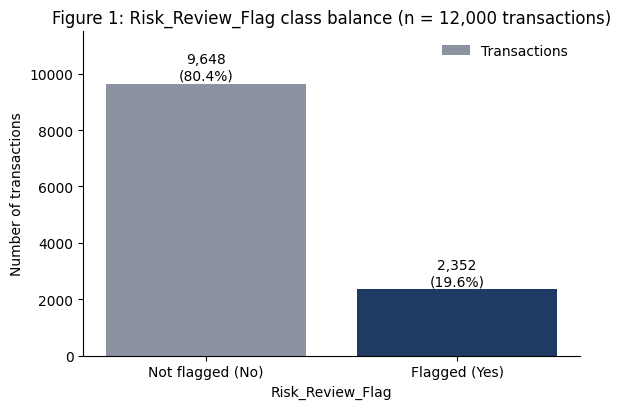

In [31]:
def plot_target_balance(df: pd.DataFrame, save_path: Path) -> None:
    """Plot and save the class balance of Risk_Review_Flag.

    Args:
        df: Transaction dataset.
        save_path: Destination path for the saved PNG figure.
    """
    counts = df["Risk_Review_Flag"].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4.2))
    bars = ax.bar(["Not flagged (No)", "Flagged (Yes)"], [counts["No"], counts["Yes"]],
                  color=[GREY, NAVY], label="Transactions")
    for bar, value in zip(bars, [counts["No"], counts["Yes"]]):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 150,
                f"{value:,}\n({value / len(df) * 100:.1f}%)", ha="center", fontsize=10)
    ax.set_title("Figure 1: Risk_Review_Flag class balance (n = 12,000 transactions)")
    ax.set_xlabel("Risk_Review_Flag")
    ax.set_ylabel("Number of transactions")
    ax.set_ylim(0, 11500)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()


plot_target_balance(transactions, FIG_DIR / "fig1_target_class_balance.png")

The target is binary, fully populated and moderately imbalanced at roughly **1:4.1**
(19.6% flagged). Two decisions follow:

- **Accuracy is excluded** as a headline metric — predicting `"No"` for everything scores 80.4%
  while detecting nothing. ROC-AUC, PR-AUC, recall and precision are used instead.
- **Imbalance is moderate**, not severe, so `class_weight="balanced"` is the proportionate first
  response. SMOTE will only be evaluated as a comparison, applied *inside* cross-validation folds.

## 6. Numerical distributions

In [32]:
numeric_summary = pd.concat([
    customers[["Age", "Tenure_Months", "Digital_Engagement_Score"]].describe().T,
    transactions[["Amount_NGN"]].describe().T,
])
numeric_summary["skew"] = [
    customers["Age"].skew(), customers["Tenure_Months"].skew(),
    customers["Digital_Engagement_Score"].skew(), transactions["Amount_NGN"].skew(),
]
numeric_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
Age,1500.0,41.59,13.73,18.00,29.75,42.00,53.00,65.00,-0.05
Tenure_Months,1500.0,49.86,27.91,1.00,26.00,51.00,74.00,96.00,-0.07
Digital_Engagement_Score,1500.0,67.95,17.56,16.70,56.10,68.00,80.93,100.00,-0.19
Amount_NGN,12000.0,46706.45,86028.72,100.17,2192.22,10305.94,48484.48,693454.45,3.20


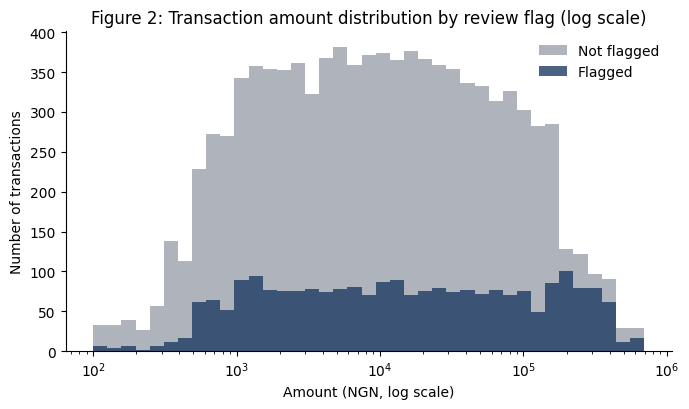

In [33]:
def plot_amount_by_flag(df: pd.DataFrame, save_path: Path) -> None:
    """Plot transaction amount distribution split by review flag, on a log scale.

    A log scale is used because the amount distribution is strongly right-skewed
    (mean roughly 4.5x the median), which hides structure on a linear axis.

    Args:
        df: Transaction dataset.
        save_path: Destination path for the saved PNG figure.
    """
    amounts = df["Amount_NGN"]
    bins = np.logspace(np.log10(amounts.min()), np.log10(amounts.max()), 40)
    flagged = df["Risk_Review_Flag"] == "Yes"

    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.hist(amounts[~flagged], bins=bins, alpha=0.7, color=GREY, label="Not flagged")
    ax.hist(amounts[flagged], bins=bins, alpha=0.8, color=NAVY, label="Flagged")
    ax.set_xscale("log")
    ax.set_title("Figure 2: Transaction amount distribution by review flag (log scale)")
    ax.set_xlabel("Amount (NGN, log scale)")
    ax.set_ylabel("Number of transactions")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()


plot_amount_by_flag(transactions, FIG_DIR / "fig2_amount_by_flag.png")

`Amount_NGN` is strongly right-skewed. For the linear baseline a log transformation will be applied;
tree-based models will use the raw value, since they are invariant to monotonic transformations.

## 7. Descriptive target profiling

> **These are descriptive rates, not test results.** Nothing in this section establishes an
> association. Its only purpose is to decide which hypotheses and features are worth taking into
> Week 2, where they will be tested formally with effect sizes reported alongside p-values.

In [34]:
def flag_rate_by(df: pd.DataFrame, column: str, target: str = "Risk_Review_Flag") -> pd.DataFrame:
    """Compute the descriptive review-flag rate within each level of a column.

    Args:
        df: Dataset containing both the column and the target.
        column: Grouping column.
        target: Target column, assumed to take the values "Yes"/"No".

    Returns:
        DataFrame of flag rate (%) and record count per level, sorted descending by rate.
    """
    flag = (df[target] == "Yes").astype(int)
    grouped = flag.groupby(df[column], dropna=False).agg(["mean", "count"])
    grouped.columns = ["flag_rate_pct", "n"]
    grouped["flag_rate_pct"] = (grouped["flag_rate_pct"] * 100).round(1)
    return grouped.sort_values("flag_rate_pct", ascending=False)


for col in ["Transaction_Type", "Channel", "International_Transaction", "Transaction_Status"]:
    print(f"\n=== Descriptive flag rate by {col} ===")
    print(flag_rate_by(transactions, col))


=== Descriptive flag rate by Transaction_Type ===
                  flag_rate_pct     n
Transaction_Type                     
Transfer                   28.5  3549
Cash Withdrawal            25.3  1430
Deposit                    16.2  1328
Airtime/Data               15.2  1185
Card Purchase              13.0  3033
Bill Payment               12.8  1475

=== Descriptive flag rate by Channel ===
            flag_rate_pct     n
Channel                        
Web                  21.3  1869
ATM                  21.2  1747
Mobile App           19.4  5102
POS                  18.3  2393
USSD                 17.3   889

=== Descriptive flag rate by International_Transaction ===
                           flag_rate_pct      n
International_Transaction                      
Yes                                 36.9    480
No                                  18.9  11520

=== Descriptive flag rate by Transaction_Status ===
                    flag_rate_pct      n
Transaction_Status               

### 7.1 Time of day

This is where my original Week 1 hypothesis needed revising.

In [35]:
transactions["Transaction_Hour"] = transactions["Transaction_DateTime"].dt.hour
hourly = flag_rate_by(transactions, "Transaction_Hour").sort_index()

windows = {
    "Overnight 00:00-05:59": transactions["Transaction_Hour"] < 6,
    "Daytime 06:00-21:59": transactions["Transaction_Hour"].between(6, 21),
    "Late evening 22:00-23:59": transactions["Transaction_Hour"] >= 22,
}
flag = (transactions["Risk_Review_Flag"] == "Yes").astype(int)
for label, mask in windows.items():
    print(f"{label:26s} flag rate {flag[mask].mean() * 100:5.1f}%   n = {mask.sum():,}")

Overnight 00:00-05:59      flag rate  28.4%   n = 3,000
Daytime 06:00-21:59        flag rate  16.9%   n = 8,000
Late evening 22:00-23:59   flag rate  15.3%   n = 1,000


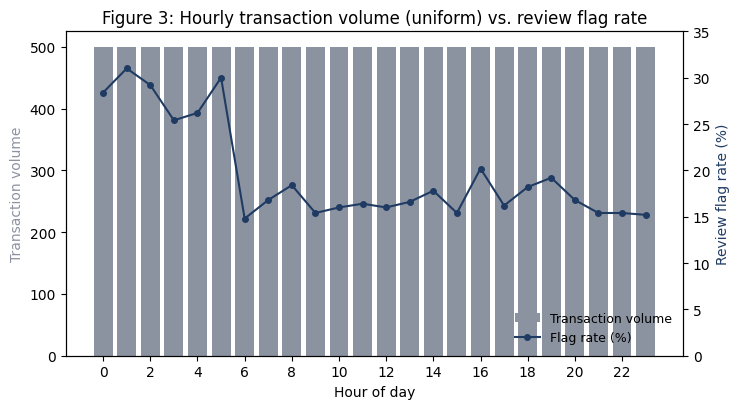

In [36]:
def plot_hourly_pattern(df: pd.DataFrame, save_path: Path) -> None:
    """Plot hourly transaction volume against the descriptive review-flag rate.

    Volume is plotted to make the uniform generation of the synthetic data visible,
    which is itself a data-quality observation.

    Args:
        df: Transaction dataset with a Transaction_Hour column.
        save_path: Destination path for the saved PNG figure.
    """
    volume = df.groupby("Transaction_Hour").size()
    rate = (df["Risk_Review_Flag"] == "Yes").groupby(df["Transaction_Hour"]).mean() * 100

    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.bar(volume.index, volume.values, color=GREY, label="Transaction volume")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Transaction volume", color=GREY)
    ax.set_xticks(range(0, 24, 2))

    ax2 = ax.twinx()
    ax2.plot(rate.index, rate.values, color=NAVY, marker="o", markersize=4, label="Flag rate (%)")
    ax2.set_ylabel("Review flag rate (%)", color=NAVY)
    ax2.set_ylim(0, 35)

    handles = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax.legend(handles, labels, loc="lower right", frameon=False, fontsize=9)
    ax.set_title("Figure 3: Hourly transaction volume (uniform) vs. review flag rate")
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()


plot_hourly_pattern(transactions, FIG_DIR / "fig3_hourly_volume_vs_flagrate.png")

**Hypothesis revision recorded.** My original H5 defined off-hours as *before 07:00 or after 22:00*.
The profile shows the elevated window is narrower than that: 00:00–05:59 sits well above the daytime
rate, while 22:00–23:59 sits slightly *below* it. H5 has been restated as an overnight
(00:00–05:59) hypothesis **before** testing, not after seeing a test result.

**Data-quality observation.** Transaction volume is *exactly* uniform — 500 transactions in every
hour of the day. Real banking volume is never uniform, so no volume-based seasonality or
burst-detection analysis is credible on this data.

### 7.2 Amount bands

In [37]:
amount_bands = pd.qcut(transactions["Amount_NGN"], 5)
band_rates = (transactions["Risk_Review_Flag"] == "Yes").groupby(amount_bands, observed=True).agg(["mean", "count"])
band_rates.columns = ["flag_rate", "n"]
band_rates["flag_rate"] = (band_rates["flag_rate"] * 100).round(1)
print(band_rates)

print("\nFlag rate above selected amount thresholds:")
for threshold in [50_000, 100_000, 200_000]:
    mask = transactions["Amount_NGN"] > threshold
    rate = (transactions.loc[mask, "Risk_Review_Flag"] == "Yes").mean() * 100
    print(f"  > NGN {threshold:>7,}: {rate:5.1f}%   n = {mask.sum():,}")

                        flag_rate     n
Amount_NGN                             
(100.169, 1588.736]          17.8  2400
(1588.736, 5558.784]         17.6  2400
(5558.784, 18819.748]        17.5  2400
(18819.748, 68264.492]       18.4  2400
(68264.492, 693454.45]       26.8  2400

Flag rate above selected amount thresholds:
  > NGN  50,000:  25.4%   n = 2,943
  > NGN 100,000:  30.0%   n = 1,729
  > NGN 200,000:  40.5%   n = 735


The relationship is **not linear**: the rate is flat across the lower four quintiles and rises only
in the upper tail. A single linear term will not capture this, which is a direct argument for either
binning the amount or using a tree-based model — recorded here as a modelling decision, not a result.

### 7.3 Customer-level attributes

The merged table is built here purely for profiling. The modelling merge happens in Week 2, after the split.

In [38]:
merged = transactions.merge(customers, on="Customer_ID", how="inner", validate="many_to_one")
assert len(merged) == len(transactions), "Merge changed the row count - check for duplicate customer keys"

for col in ["Customer_Segment", "Account_Type", "Account_Status", "Monthly_Income_Band"]:
    print(f"\n=== Descriptive flag rate by {col} ===")
    print(flag_rate_by(merged, col))

merged["Tenure_Band"] = pd.cut(merged["Tenure_Months"], [0, 12, 36, 60, 96])
print("\n=== Descriptive flag rate by tenure band ===")
print(flag_rate_by(merged, "Tenure_Band"))


=== Descriptive flag rate by Customer_Segment ===
                  flag_rate_pct     n
Customer_Segment                     
Premium                    20.3  2361
Student                    19.7  2289
SME                        19.4  1706
Everyday                   19.3  5644

=== Descriptive flag rate by Account_Type ===
              flag_rate_pct     n
Account_Type                     
Premium                20.1  1828
Savings                20.1  7149
Current                18.0  3023

=== Descriptive flag rate by Account_Status ===
                flag_rate_pct      n
Account_Status                      
Restricted               22.3    224
Dormant                  20.4    866
Active                   19.5  10910

=== Descriptive flag rate by Monthly_Income_Band ===
                     flag_rate_pct     n
Monthly_Income_Band                     
250k-499k                     20.2  3357
100k-249k                     20.1  3336
Below 100k                    19.3  2129
1m+        

/tmp/ipykernel_609/4158115917.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = flag.groupby(df[column], dropna=False).agg(["mean", "count"])


**The most consequential observation in this notebook.** Flag rates vary materially across
*transaction* attributes but are close to flat across *customer* attributes — segment, account type,
income band and tenure all sit within roughly one percentage point of the overall 19.6% rate.

This suggests the synthetic label was generated principally from transaction-level fields. It is a
property of this dataset, not a statement about banking risk. The customer features will still be
tested properly in Week 2 — a weak marginal association can still matter in interaction — but I am
recording the expectation of a **modest performance ceiling in advance of the results**, so that a
lower-than-hoped AUC is reported as a finding rather than tuned away.

### 7.4 Category comparison figure

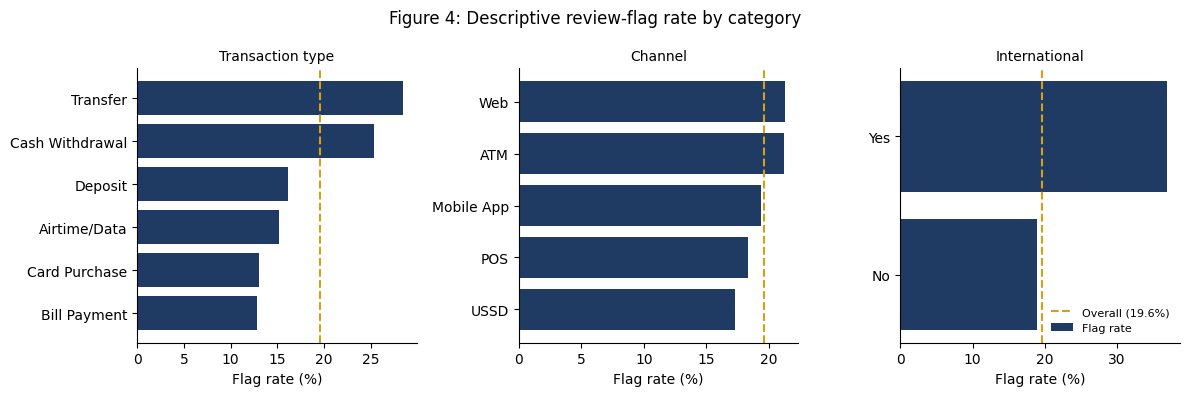

In [39]:
def plot_flagrate_by_categories(df: pd.DataFrame, columns: list[str], titles: list[str],
                                save_path: Path) -> None:
    """Plot descriptive flag rates for several categorical fields side by side.

    Args:
        df: Transaction dataset.
        columns: Categorical column names to plot.
        titles: Display titles, one per column.
        save_path: Destination path for the saved PNG figure.
    """
    overall = (df["Risk_Review_Flag"] == "Yes").mean() * 100
    fig, axes = plt.subplots(1, len(columns), figsize=(12, 4))
    for ax, column, title in zip(axes, columns, titles):
        rates = flag_rate_by(df, column)["flag_rate_pct"].sort_values()
        ax.barh(rates.index.astype(str), rates.values, color=NAVY, label="Flag rate")
        ax.axvline(overall, color=GOLD, linestyle="--", linewidth=1.5,
                   label=f"Overall ({overall:.1f}%)")
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Flag rate (%)")
        ax.spines[["top", "right"]].set_visible(False)
    axes[-1].legend(frameon=False, fontsize=8, loc="lower right")
    fig.suptitle("Figure 4: Descriptive review-flag rate by category")
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()


plot_flagrate_by_categories(
    transactions,
    ["Transaction_Type", "Channel", "International_Transaction"],
    ["Transaction type", "Channel", "International"],
    FIG_DIR / "fig4_flagrate_by_category.png",
)

## 8. Data-quality observations

The checks below produce the observations recorded in Section 8.4 of the Week 1 report.

In [40]:
# DQ4 - Channel and Device_Type consistency
print("Channel x Device_Type (expect a near-diagonal structure in coherent data):")
print(pd.crosstab(transactions["Channel"], transactions["Device_Type"]))

Channel x Device_Type (expect a near-diagonal structure in coherent data):
Device_Type  ATM Terminal  Android  POS Terminal  Web Browser   iOS
Channel                                                            
ATM                   176      660           234          219   447
Mobile App            524     2059           618          608  1251
POS                   210      968           324          298   570
USSD                   87      374           123          109   190
Web                   172      736           272          213   462


In [41]:
# DQ5 - transaction Location vs the customer's recorded home City
location_mismatch = (merged["Location"].notna() & (merged["Location"] != merged["City"])).mean()
print(f"DQ5  Transactions in a city other than the customer's home city: {location_mismatch:.1%}")

# DQ6 - tenure implausible relative to age
implausible_tenure = customers["Tenure_Months"] > (customers["Age"] - 18) * 12
print(f"DQ6  Customers whose tenure exceeds (age - 18) years: {implausible_tenure.sum()}")

# DQ7 - Customer_Name is not an identifier
print(f"DQ7  Duplicated customer names: {customers['Customer_Name'].duplicated().sum()} of {len(customers)}")

# DQ3 - temporal uniformity
per_day = transactions["Transaction_DateTime"].dt.date.value_counts()
per_hour = transactions["Transaction_Hour"].value_counts()
print(f"DQ3  Transactions per day: min {per_day.min()}, max {per_day.max()} over {per_day.size} days")
print(f"DQ3  Transactions per hour: min {per_hour.min()}, max {per_hour.max()}")

# DQ8 - semantically unusual international combinations
international = transactions[transactions["International_Transaction"] == "Yes"]
print("\nDQ8  Transaction types recorded as international:")
print(international["Transaction_Type"].value_counts())

DQ5  Transactions in a city other than the customer's home city: 86.5%
DQ6  Customers whose tenure exceeds (age - 18) years: 145
DQ7  Duplicated customer names: 1320 of 1500
DQ3  Transactions per day: min 133, max 134 over 90 days
DQ3  Transactions per hour: min 500, max 500

DQ8  Transaction types recorded as international:
Transaction_Type
Transfer           150
Card Purchase      125
Deposit             57
Bill Payment        56
Airtime/Data        50
Cash Withdrawal     42
Name: count, dtype: int64


## 9. Summary and Week 2 entry point

**Established in Week 1**

| Question | Answer |
|---|---|
| Is the target usable? | Yes — binary, complete, 19.6% positive (1:4.1) |
| Does the join hold? | Yes — one-to-many on `Customer_ID`, full referential integrity both ways |
| Is the data clean enough? | Yes, with ten documented issues to treat in Week 2 |
| Where does the signal appear to sit? | Transaction-level attributes, not customer-level attributes |
| Primary metric | ROC-AUC (target ≥ 0.75), with recall ≥ 0.70 as the binding constraint |

**First actions in Week 2**

1. Create the stratified 70/15/15 split **before** any further exploratory analysis.
2. Build the feature pipeline (time features, customer-relative amount, 7-day transaction count),
   fitted on training folds only.
3. Formally test H1–H5 with effect sizes alongside p-values.
4. Fit the logistic regression baseline with `class_weight="balanced"`.
5. Run the `Transaction_Status` leakage test: train paired models with and without the field.

---

